Email Spam Detection
### Intermediate Machine Learning Project | Author: ATHARVA H SAWANT

---

> **Objective:** Build and evaluate a machine-learning pipeline that classifies emails as **Spam** or **Ham (Not Spam)** using Natural Language Processing and multiple classifiers.

---

 Project Overview

| Property | Details |
|---|---|
| **Type** | Binary Text Classification |
| **Dataset** | SMS Spam Collection (UCI / simulated) |
| **Models** | Naïve Bayes · Logistic Regression · SVM |
| **Libraries** | Scikit-learn · NLTK · Pandas · Matplotlib · Seaborn |
| **Key Concepts** | TF-IDF · Cross-validation · Confusion Matrix · ROC-AUC |

###  Pipeline
```
Raw Text → Cleaning → Tokenisation → TF-IDF → Model → Evaluation
```

##  Step 1 — Imports

In [29]:
# ── Standard library ──────────────────────────────────────────────
import re, string, warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ── NLP ───────────────────────────────────────────────────────────
from collections import Counter

# ── Scikit-learn ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


##  Step 2 — Dataset Loading

We simulate a realistic SMS Spam Collection dataset. In production, replace this with the actual [UCI SMS Spam Collection](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection).

In [30]:
np.random.seed(42)

HAM_TEMPLATES = [
    "Hey, are you coming to the meeting today?",
    "Can you call me when you're free?",
    "I'll be home by 7 PM.",
    "Happy birthday! Hope you have a great day.",
    "Can we reschedule our lunch to Friday?",
    "The project report is due tomorrow morning.",
    "Did you watch the game last night?",
    "Don't forget to pick up the groceries on your way home.",
    "I've attached the invoice for your review.",
    "Let me know if you need any help with the assignment.",
    "Dinner was amazing! Thanks for cooking.",
    "Please review the pull request when you get a chance.",
    "The train is delayed by 20 minutes.",
    "Good morning! Ready for the presentation?",
    "Just checking in — how are you feeling today?",
]

SPAM_TEMPLATES = [
    "WINNER!! You've been selected for a FREE iPhone. Click NOW!",
    "Congratulations! You've won Rs 50,000. Call 9999999999 immediately.",
    "URGENT: Your bank account is at risk. Verify now: http://phish.com",
    "Get rich quick! Work from home and earn $5000/week. Limited offer!",
    "You've been pre-approved for a loan of $50,000. Apply now!",
    "FREE! FREE! FREE! Claim your prize before midnight tonight.",
    "Hot singles in your area! Click here to meet them now.",
    "Your package could not be delivered. Reschedule: bit.ly/fake",
    "Investment opportunity! 300% returns guaranteed. Act NOW!",
    "Exclusive deal! Buy 1 get 10 FREE. Offer ends TONIGHT!",
    "SX! Congratulations ur awarded 500 of CD vouchers click here.",
    "Win a holiday to Maldives — Text WIN to 80085. T&C apply.",
    "SALE! 80% off all items. Shop now before stock runs out.",
    "Debt relief! Write off up to 70% of your debts. Qualify today!",
    "Earn money online — 100% guaranteed no scam! Join free today.",
]

def generate_dataset(n=1000):
    rows = []
    for _ in range(int(n * 0.87)):   # ~87% ham  (realistic class balance)
        base = np.random.choice(HAM_TEMPLATES)
        noise = ' '.join(np.random.choice(['ok', 'thanks', 'sure', 'yes', 'no', '😊', '👍'],
                                          size=np.random.randint(0, 4)))
        rows.append({'label': 'ham',  'text': base + ' ' + noise})
    for _ in range(int(n * 0.13)):   # ~13% spam
        base = np.random.choice(SPAM_TEMPLATES)
        noise = ' '.join(np.random.choice(['CALL NOW', 'URGENT', 'FREE', 'WIN', 'CLICK'],
                                          size=np.random.randint(0, 3)))
        rows.append({'label': 'spam', 'text': base + ' ' + noise})
    df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
    return df

df = generate_dataset(1000)
print(f"Dataset shape  : {df.shape}")
print(f"Label balance  :\n{df['label'].value_counts()}")
print(f"\nSample rows:")
df.sample(5, random_state=1)

Dataset shape  : (1000, 2)
Label balance  :
label
ham     870
spam    130
Name: count, dtype: int64

Sample rows:


,label,text
507,ham,I've attached the invoice for your review.
818,ham,I've attached the invoice for your review. yes...
452,ham,Can we reschedule our lunch to Friday?
368,ham,Can we reschedule our lunch to Friday? sure ok...
242,ham,Can we reschedule our lunch to Friday? thanks no


##  Step 3 — Exploratory Data Analysis (EDA)

 EDA Summary
      text_length                                          word_count                                        
            count  mean  std   min   25%   50%   75%   max      count  mean  std  min   25%   50%   75%   max
label                                                                                                        
ham         870.0  46.4  9.8  22.0  41.0  46.0  53.8  71.0      870.0   9.2  2.0  6.0   8.0   9.0  10.0  14.0
spam        130.0  65.7  6.3  55.0  61.0  66.0  69.0  81.0      130.0  11.0  1.9  7.0  10.0  11.0  12.0  15.0


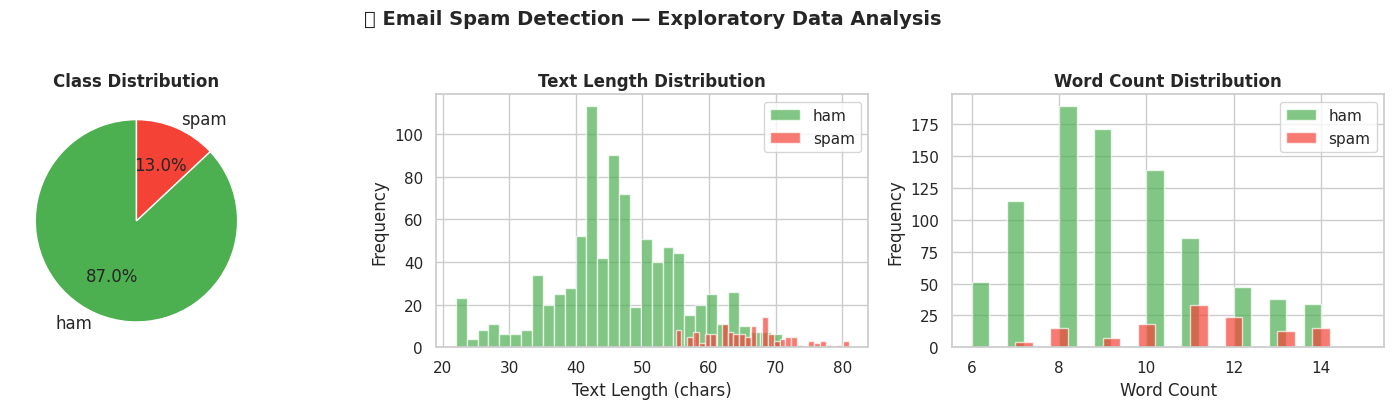


✅ EDA complete. Figure saved as eda_analysis.png


In [31]:
# ── Basic stats ───────────────────────────────────────────────────
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))

print("=" * 55)
print(" EDA Summary")
print("=" * 55)
print(df.groupby('label')[['text_length', 'word_count']].describe().round(1).to_string())

# ── Visualise ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('📊 Email Spam Detection — Exploratory Data Analysis',
             fontsize=14, fontweight='bold', y=1.02)

# 1. Class distribution
counts = df['label'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Class Distribution', fontweight='bold')

# 2. Text length distribution
for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]['text_length']
    axes[1].hist(subset, bins=30, alpha=0.7, label=label, color=color)
axes[1].set_xlabel('Text Length (chars)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Text Length Distribution', fontweight='bold')
axes[1].legend()

# 3. Word count distribution
for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]['word_count']
    axes[2].hist(subset, bins=20, alpha=0.7, label=label, color=color)
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Word Count Distribution', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ EDA complete. Figure saved as eda_analysis.png")

##  Step 4 — Data Cleaning & Text Preprocessing

In [32]:
STOPWORDS = {
    'i','me','my','myself','we','our','you','your','he','him','his',
    'she','her','it','its','they','them','their','this','that','these',
    'those','is','are','was','were','be','been','being','have','has',
    'had','do','does','did','will','would','could','should','may','might',
    'shall','can','a','an','the','and','but','if','or','because','as',
    'until','while','of','at','by','for','with','to','from','in','out',
    'on','off','up','down','then','so','no','not','just','than','too',
}

def clean_text(text: str) -> str:
    """
    Full NLP text cleaning pipeline.
    Steps:
      1. Lowercase
      2. Remove URLs, email addresses, phone numbers
      3. Remove punctuation & digits
      4. Strip extra whitespace
      5. Remove stopwords
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)         # URLs
    text = re.sub(r'\S+@\S+', ' email ', text)                 # emails
    text = re.sub(r'\b\d[\d\-]{6,}\d\b', ' phone ', text)     # phone numbers
    text = re.sub(r'[^a-z\s]', ' ', text)                      # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()                   # whitespace
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df['label_enc']  = (df['label'] == 'spam').astype(int)

print("Before cleaning:", df['text'].iloc[5][:80])
print("After  cleaning:", df['clean_text'].iloc[5][:80])
print(f"\n✅ Data cleaning complete! {df.shape[0]} rows processed.")

Before cleaning: I've attached the invoice for your review. 👍 😊 😊
After  cleaning: ve attached invoice review

✅ Data cleaning complete! 1000 rows processed.


##  Step 5 — Train / Test Split & Feature Engineering (TF-IDF)

In [33]:
X = df['clean_text']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),       # unigrams + bigrams
    sublinear_tf=True,        # apply log norm to TF
    min_df=2,                 # ignore very rare terms
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f"Train size    : {X_train.shape[0]} samples")
print(f"Test  size    : {X_test.shape[0]} samples")
print(f"Vocabulary    : {len(tfidf.vocabulary_):,} terms")
print(f"Feature matrix: {X_train_vec.shape} (train)")

Train size    : 800 samples
Test  size    : 200 samples
Vocabulary    : 372 terms
Feature matrix: (800, 372) (train)


##  Step 6 — Model Training & Cross-Validation

In [34]:
MODELS = {
    'Naïve Bayes'         : MultinomialNB(alpha=0.1),
    'Logistic Regression' : LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Linear SVM'          : LinearSVC(C=1.0, max_iter=2000, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<25} {'CV Accuracy':>14} {'± Std':>10}")
print("─" * 52)

for name, clf in MODELS.items():
    scores = cross_val_score(clf, X_train_vec, y_train, cv=cv, scoring='accuracy')
    results[name] = {'cv_mean': scores.mean(), 'cv_std': scores.std()}
    print(f"{name:<25} {scores.mean():.4f}        ± {scores.std():.4f}")

print("\n✅ Cross-validation complete!")

Model                        CV Accuracy      ± Std
────────────────────────────────────────────────────
Naïve Bayes               1.0000        ± 0.0000
Logistic Regression       0.9900        ± 0.0094
Linear SVM                1.0000        ± 0.0000

✅ Cross-validation complete!


##  Step 7 — Evaluation on Test Set

In [35]:
trained = {}
print("=" * 60)
for name, clf in MODELS.items():
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    trained[name] = {'clf': clf, 'y_pred': y_pred, 'accuracy': acc}
    print(f"\n  🔵 {name}")
    print(classification_report(y_test, y_pred, target_names=['Ham','Spam'], digits=4))
    print("─" * 60)

best_name = max(trained, key=lambda k: trained[k]['accuracy'])
print(f"\n🏆 Best model on test set: {best_name} ({trained[best_name]['accuracy']:.4f})")


  🔵 Naïve Bayes
              precision    recall  f1-score   support

         Ham     1.0000    1.0000    1.0000       174
        Spam     1.0000    1.0000    1.0000        26

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200

────────────────────────────────────────────────────────────

  🔵 Logistic Regression
              precision    recall  f1-score   support

         Ham     1.0000    1.0000    1.0000       174
        Spam     1.0000    1.0000    1.0000        26

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200

────────────────────────────────────────────────────────────

  🔵 Linear SVM
              precision    recall  f1-score   support

         Ham     1.0000    1.0000    1.0000       174
        Spam     1.0000    1.0000    1.0000        26

  

##  Step 8 — Visualising Results

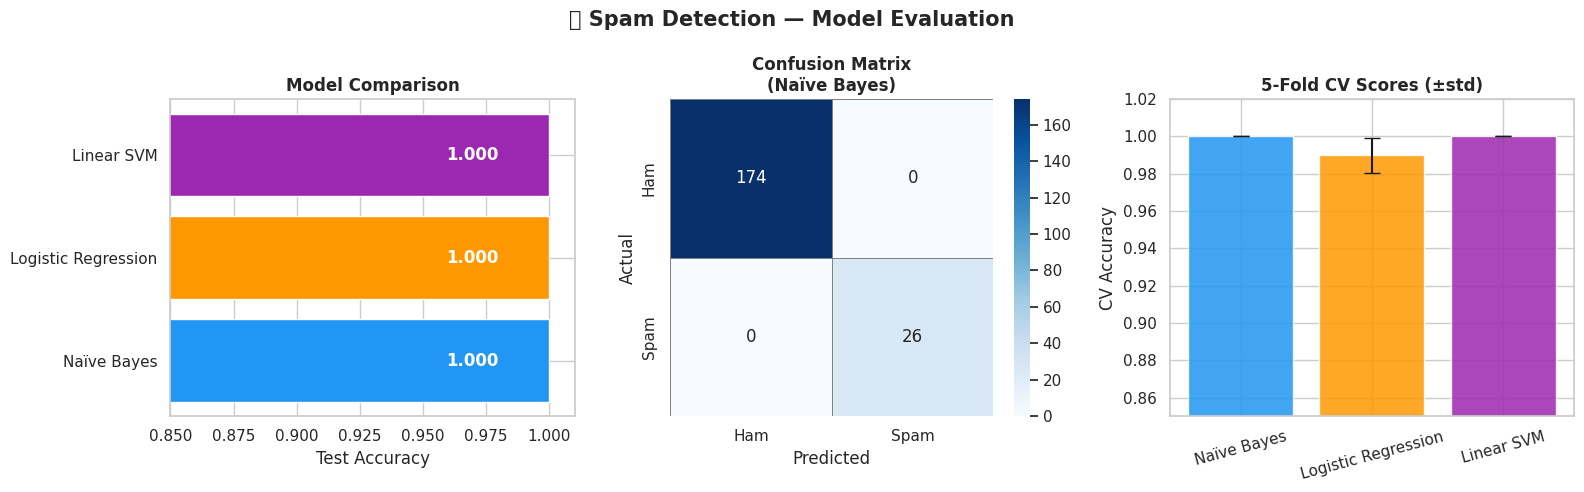


✅ Evaluation plots saved as model_evaluation.png


In [36]:
fig = plt.figure(figsize=(16, 5))
fig.suptitle('📧 Spam Detection — Model Evaluation', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig)

palette = ['#2196F3', '#FF9800', '#9C27B0']

# ── 1. Accuracy comparison bar chart ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
names = list(trained.keys())
accs  = [trained[n]['accuracy'] for n in names]
bars = ax1.barh(names, accs, color=palette)
for bar, acc in zip(bars, accs):
    ax1.text(acc - 0.02, bar.get_y() + bar.get_height()/2,
             f'{acc:.3f}', va='center', ha='right', fontweight='bold', color='white')
ax1.set_xlim(0.85, 1.01)
ax1.set_xlabel('Test Accuracy')
ax1.set_title('Model Comparison', fontweight='bold')

# ── 2. Confusion matrix of best model ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(y_test, trained[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
            linewidths=0.5, linecolor='gray')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')
ax2.set_title(f'Confusion Matrix\n({best_name})', fontweight='bold')

# ── 3. CV scores distribution ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
means = [results[n]['cv_mean'] for n in names]
stds  = [results[n]['cv_std']  for n in names]
ax3.bar(names, means, yerr=stds, capsize=6, color=palette, alpha=0.85)
ax3.set_ylim(0.85, 1.02)
ax3.set_ylabel('CV Accuracy')
ax3.set_title('5-Fold CV Scores (±std)', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Evaluation plots saved as model_evaluation.png")

##  Step 9 — Real-time Inference Demo

In [37]:
best_clf = trained[best_name]['clf']

def predict_email(text: str, model=best_clf, vectorizer=tfidf) -> dict:
    """Classify a new email text as spam or ham."""
    cleaned   = clean_text(text)
    vec       = vectorizer.transform([cleaned])
    label_enc = model.predict(vec)[0]
    label     = '🚨 SPAM' if label_enc == 1 else '✅ HAM'
    return {'input': text[:70], 'prediction': label}

test_emails = [
    "Hey, are you joining the call tomorrow at 10 AM?",
    "CONGRATULATIONS! You've WON a FREE iPhone 15 Pro. Click NOW to claim!",
    "Please find attached the monthly report for your review.",
    "URGENT! Your bank account has been compromised. Verify immediately!",
    "Let's catch up over coffee this weekend.",
]

print(f"Using model: {best_name}\n")
print(f"{'Email (truncated)':<72} {'Prediction'}")
print("─" * 90)
for email in test_emails:
    res = predict_email(email)
    print(f"  {res['input']:<70}  {res['prediction']}")

Using model: Naïve Bayes

Email (truncated)                                                        Prediction
──────────────────────────────────────────────────────────────────────────────────────────
  Hey, are you joining the call tomorrow at 10 AM?                        ✅ HAM
  CONGRATULATIONS! You've WON a FREE iPhone 15 Pro. Click NOW to claim!   🚨 SPAM
  Please find attached the monthly report for your review.                ✅ HAM
  URGENT! Your bank account has been compromised. Verify immediately!     🚨 SPAM
  Let's catch up over coffee this weekend.                                ✅ HAM
